In [1]:
%pip install matplotlib scikit-learn numpy
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits

# Veriyi yükleme
digits = load_digits()
X, y = digits.data, digits.target

# İlk kontrol
print(f"Toplam Görsel Sayısı (Örnek): {X.shape[0]}")
print(f"Her Bir Görselin Piksel Sayısı (Öznitelik): {X.shape[1]}")
print(f"Hedef Sınıflar: {np.unique(y)}")


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\onurp\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Toplam Görsel Sayısı (Örnek): 1797
Her Bir Görselin Piksel Sayısı (Öznitelik): 64
Hedef Sınıflar: [0 1 2 3 4 5 6 7 8 9]


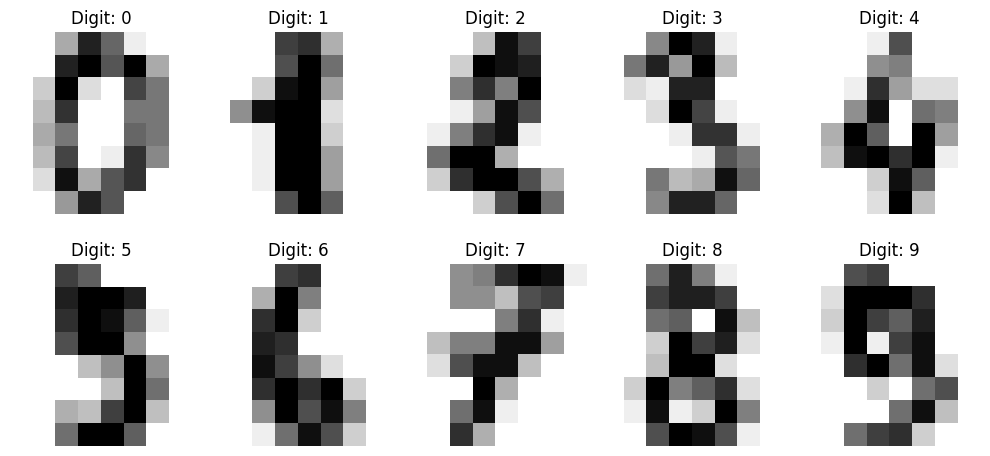

In [2]:
# 10 rakamı yan yana İngilizce başlıklarla görselleştirme
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray_r', interpolation='nearest')
    ax.set_title(f"Digit: {y[i]}") # Burayı 'Digit' yaptık
    ax.axis('off')

plt.tight_layout()
plt.savefig('digits_eda.png', dpi=300)
plt.show()

In [3]:
from sklearn.model_selection import train_test_split

# %80 Eğitim, %20 Test olarak bölüyoruz. 
# stratify=y sayesinde her rakamdan eşit oranda (dengeli) bölünme sağlanır.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Eğitim Seti Boyutu: {X_train.shape}")
print(f"Test Seti Boyutu: {X_test.shape}")

Eğitim Seti Boyutu: (1437, 64)
Test Seti Boyutu: (360, 64)


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Sadece train setini fit_transform yapıyoruz
X_train_scaled = scaler.fit_transform(X_train)

# Test setini sadece transform yapıyoruz (modele dair hiçbir bilgi sızmasın diye)
X_test_scaled = scaler.transform(X_test)

print("Ölçeklendirme başarıyla tamamlandı!")

Ölçeklendirme başarıyla tamamlandı!


In [ ]:

from sklearn.model_selection import train_test_split, GridSearchCV 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# (Veri Yükleme ve Bölme 80 eğitim, 20 test olmak üzere)
digits = load_digits()
X, y = digits.data, digits.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# - MODEL 1: Logistic Regression

log_reg = LogisticRegression(solver='lbfgs', max_iter=5000, random_state=42)

log_reg_params = {'C': [0.1, 1, 10]}

grid_log = GridSearchCV(log_reg, log_reg_params, cv=5, scoring='accuracy', n_jobs=-1)
grid_log.fit(X_train_scaled, y_train)

print("\n--- LOGISTIC REGRESSION RESULTS ---")
print(f"En İyi Parametre (Best C): {grid_log.best_params_}")
print(f"En İyi 5-Fold CV Skoru: %{grid_log.best_score_ * 100:.2f}")

# - MODEL 2: SVM (Çalışması 30-40 sn sürebilir)
svm_model = SVC(random_state=42)
svm_params = {
    'C': [1, 10],
    'kernel': ['rbf', 'linear']
}

grid_svm = GridSearchCV(svm_model, svm_params, cv=5, scoring='accuracy', n_jobs=-1)
grid_svm.fit(X_train_scaled, y_train)

print("\n--- SUPPORT VECTOR MACHINES (SVM) RESULTS ---")
print(f"En İyi Parametreler: {grid_svm.best_params_}")
print(f"En İyi 5-Fold CV Skoru: %{grid_svm.best_score_ * 100:.2f}")


1. LOGISTIC REGRESSION FINAL TEST REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.89      0.89      0.89        36
           2       1.00      1.00      1.00        35
           3       0.97      1.00      0.99        37
           4       0.97      1.00      0.99        36
           5       1.00      1.00      1.00        37
           6       1.00      0.97      0.99        36
           7       1.00      1.00      1.00        36
           8       0.89      0.89      0.89        35
           9       1.00      0.97      0.99        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360


2. SUPPORT VECTOR MACHINES (SVM) FINAL TEST REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.95      0.97     

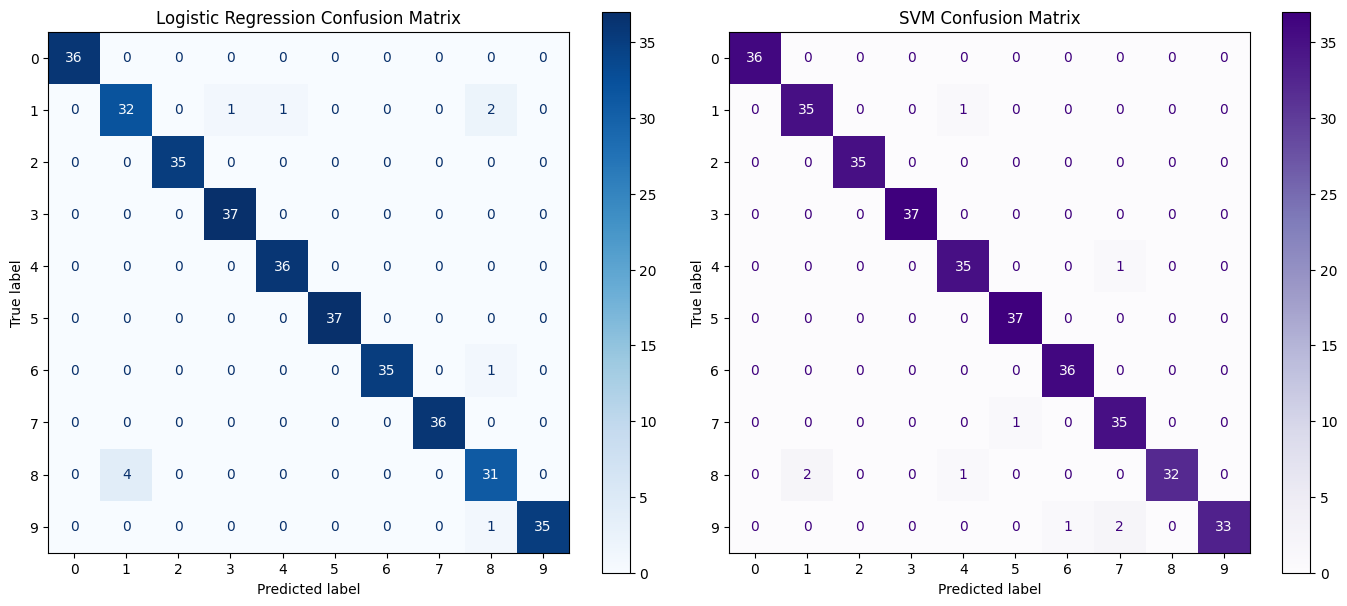


--- Başarıyla Tamamlandı! 'confusion_matrices.png' klasörünüze kaydedildi. ---


In [7]:

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# En iyi performans gösteren modelleri seçiyoruz
best_log = grid_log.best_estimator_
best_svm = grid_svm.best_estimator_

# Test verisiyle tahmin yapıyoruz
y_pred_log = best_log.predict(X_test_scaled)
y_pred_svm = best_svm.predict(X_test_scaled)

# 1. Logistic Regression Test Sonuçları
print("\n=========================================")
print("1. LOGISTIC REGRESSION FINAL TEST REPORT")
print("=========================================")
print(classification_report(y_test, y_pred_log))

# 2. SVM Test Sonuçları
print("\n=========================================")
print("2. SUPPORT VECTOR MACHINES (SVM) FINAL TEST REPORT")
print("=========================================")
print(classification_report(y_test, y_pred_svm))

# 3. Confusion Matrix (Karmaşıklık Matrisi) Grafiklerini Çizme
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ConfusionMatrixDisplay.from_estimator(best_log, X_test_scaled, y_test, ax=ax[0], cmap='Blues')
ax[0].set_title('Logistic Regression Confusion Matrix')

ConfusionMatrixDisplay.from_estimator(best_svm, X_test_scaled, y_test, ax=ax[1], cmap='Purples')
ax[1].set_title('SVM Confusion Matrix')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300) # bilgisayara kaydeder
plt.show()

print("\n--- Başarıyla Tamamlandı! 'confusion_matrices.png' klasörünüze kaydedildi. ---")